# Python Homework #2
## A weighted random walk

Prerequisites: The videos up to and including "Counting using NumPy".

## Corresponding Outcomes

## Instructions

In a group of 1-3 students, work on answering the following questions in a Jupyter notebook. Submit the ipynb file with your solutions to Canvas. You and your group members can submit the same assignment, but all of you should upload it individually to Canvas.

## Group Members

 - Group Member 1:
 - Group Member 2:
 - Group Member 3:

## Part A

* Instantiate a random number generator in NumPy and assign it the variable name `rng`.

In [18]:
import numpy as np
rng = np.random.default_rng()

* Using the `choice` method of `rng`, make a length-20 NumPy array of randomly chosen 1s and -1s, with 1 and -1 equally likely.  (Be sure you're not using any loops in this.  Instead use the `size` keyword argument of `choice`.)  Name the resulting array `x`.

In [19]:
x = rng.choice([-1,1], size = (20))

* Compute the cumulative sum of the elements in `x` using NumPy's `cumsum` function.  Name the result `y`.  Look at the values in `x` and `y` and make sure you understand how the two relate to each other.

In [4]:
y = np.cumsum(x)

In [6]:
x

array([[ 1,  1, -1,  1, -1,  1, -1, -1, -1,  1,  1,  1,  1, -1, -1,  1,
         1,  1,  1,  1]])

In [5]:
y

array([ 1,  2,  1,  2,  1,  2,  1,  0, -1,  0,  1,  2,  3,  2,  1,  2,  3,
        4,  5,  6])

* Make a length ten million NumPy array with randomly chosen 1s and -1s.  Again name the result x.
* What proportion of the values in `x` are 1? Compute this using a for loop and an if statement.  (If your answer isn't close to 0.5, then check your code for mistakes.)
* What proportion of the values in `x` are 1?  Compute this using a Boolean array, `count_nonzero` and dividing.
* What proportion of the values in `x` are 1?  Compute this using `mean`.
* (Make sure your answers are the same.)
* How do these computations compare in terms of speed?  Answer using `%%timeit`.

In [19]:
x = rng.choice([-1,1],size = (10**7))

In [20]:
x

array([-1,  1, -1, ..., -1, -1,  1])

In [27]:
%%timeit
count = 0;
for i in x:
    if i == 1:
        count += 1
count/10**7

1.16 s ± 26.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
%%timeit
np.count_nonzero(x == 1)/10**7

5.89 ms ± 109 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [29]:
%%timeit
(x == 1).mean()

15.9 ms ± 350 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Part B

Check the documentation for the `choice` method of `rng`.  Notice that there is an argument for assigning weights to the different options.
* Make a length ten million NumPy array `z` of 1s and -1s, where -1 is chosen 50.1% of the time, and where 1 is chosen 49.9% of the time.
* Check what proportion of the elements in `z` are equal to 1.  The number should be very close to 0.499 (definitely closer to 0.499 than to 0.5).

In [75]:
z = rng.choice([-1,1], size = 10**7, p = [0.501,0.499])

In [76]:
(z == 1).mean()

0.4988045

* Make the corresponding length 10 million weighted random walk corresponding to `z`.  Save the resulting NumPy array with the variable name `w`.

In [77]:
w = np.cumsum(z)

* What proportion of elements in `w` do you expect to be positive?  Compute this proportion.  Did it match your expectation?
* What is the maximum value in `w`?  What is the minimum value in `w`?
* What are the first 50 indices at which `w` has absolute value greater than 100?  Use NumPy's `nonzero` function to find this, together with two Boolean arrays and the NumPy version of or (which is not `or`), by checking where `w` is greater than 100 or is less than -100.  Store these indices with the variable name `m`.  (Remember that `nonzero` returns a tuple.)
* What was the value of `w` at these indices?  (This should be as easy evaluating `w[m]`.)

In [78]:
(w > 0).mean()

0.0027386

In [79]:
w.max()

163

In [80]:
w.min()

-24053

In [81]:
m = np.nonzero((w > 100) | (w < -100))[0][:50]

In [82]:
w[m]

array([101, 102, 101, 101, 102, 101, 101, 101, 102, 103, 104, 105, 104,
       105, 106, 107, 108, 109, 108, 107, 108, 107, 108, 109, 108, 107,
       108, 109, 110, 109, 108, 107, 108, 107, 106, 105, 104, 103, 104,
       105, 104, 105, 106, 107, 108, 109, 108, 107, 108, 109])

## Part C

* Just like there is a NumPy `zeros` function and a NumPy `ones` function, there is a NumPy `full` function which fills any value you want in.  Make a length ten million NumPy array containing the letter `"r"` in every slot (for "red").  Name this array `c`.
* Again using `nonzero`, find all the indices where `w` is positive.  (If `w` is never positive, then re-compute `w` and `z` to get new random values.)  Name the array of these indices `inds`.
* Change all the values of `c` corresponding to the `inds` indices to `"k"` (for "black") using the command `c[inds] = "k"`.
* Let `mpi` (for maximum positive index) be the maximum index where `w` is positive.
* Print `mpi`.  What proportion of the way into the walk does the value of `w` become negative and never switch back?  Answer this question in a markdown cell.

In [83]:
c = np.full(10**7, "r")

In [84]:
inds = np.nonzero((w > 0))[0]

In [85]:
c[inds] = "k"

In [86]:
mpi = np.nonzero((w > 0))[0].max()

In [87]:
print(mpi)

63988


In [88]:
mpi/10**7

0.0063988

How many times does `w` switch from positive to negative?  Here is a slick way to answer that question.  For any index `i`, the triple 
* `w[i]`, `w[i+1]`, `w[i+2]`

goes 

* positive, zero, negative

if and only if `i` is in `inds` and `i+1`, `i+2` are not in `inds`.  (Not to be turned in: try writing a proof of this, using cases.  The backwards direction of this if-and-only-if proof is the easier direction.)

We can check this condition by looking at consecutive elements in `inds`.  For example, if we know `... 240, 248, ...` are two consecutive elements in `inds`, then we know that `w[240]` was positive, `w[241]` was zero, `w[242]` was negative, ....  The key property in this example is that 248-240 > 2: there is a gap of size greater than 2 between positive indices.  We can compute all these gaps at once by computing `inds[1:]-inds[:-1]`.  For example, try evaluating the following.
```
A = np.array([1,2,3,4,8,9,10,238,239,240,248,249,250,251,252])
A[1:] - A[:-1]
```


In [67]:
A = np.array([1,2,3,4,8,9,10,238,239,240,248,249,250,251,252])
A[1:] - A[:-1]

array([  1,   1,   1,   4,   1,   1, 228,   1,   1,   8,   1,   1,   1,
         1])

In [69]:
A[:-1]

array([  1,   2,   3,   4,   8,   9,  10, 238, 239, 240, 248, 249, 250,
       251])

In [70]:
A[1:]

array([  2,   3,   4,   8,   9,  10, 238, 239, 240, 248, 249, 250, 251,
       252])

* Using that idea, compute how often `w` switches from positive to negative, by counting how often this "consecutive difference array" is greater than 2.  Use a Boolean array and the `count_nonzero` function.  And actually add 1 to this number, because the very last index also represents a switch from positive to negative.
* How often is there a gap of at least 1000 between positive indices?  Use the same strategy we just used looking for gaps of size greater than 2.
* If there are fewer than 3 of these size-1000 gaps, rerun the code (starting at the 50.1% part) to get new random numbers until there are at least 3 size-1000 gaps.
* What are the sizes of these gaps?  Use Boolean indexing.

In [94]:
np.count_nonzero((inds[1:] - inds[:-1]) > 2 ) + 1

96

In [96]:
np.count_nonzero((inds[1:] - inds[:-1]) > 1000 )

5

In [105]:
gas = (inds[1:] - inds[:-1]) > 1000

In [109]:
(inds[1:] - inds[:-1])[gaps]

array([15588,  1318,  3538,  4678,  7262])

## Part D

* Let `m0` be `mpi+10,000`.  
* Define `w0` to be the first `m0` values in `w` and define `c0` to be the first `m0` values in `c`.  (Use slicing.)
* Using NumPy's `arange` function, make the NumPy array `x` corresponding to `[0, 1, ..., (10**7)-1]` and then set `x0 = x[:m0]`.
* Using slicing, define `x1` to be every 50-th element in `x` (meaning `x[0]`, `x[50]`, ...), define `w1` to be every 50-th element in `w`, and define `c1` to be every 50-th element in `c`.


In [111]:
m0 = mpi+10000
w0 = w[:m0]
c0 = c[:m0]

In [112]:
x = np.arange(10**7)
x0 = x[:m0]
x1 = x[::50]
w1 = w[::50]
c1 = c[::50]

* As a preview of Matplotlib which will be introduced next week, evaluate the following after defining the above variables.  Don't worry about understanding this code for now.  (You may have to install Matplotlib; install it the same way you installed NumPy.)
```
import matplotlib.pyplot as plt
plt.style.use('ggplot')
fig, axs = plt.subplots(2)
axs[0].scatter(x0, w0, s=0.01, c=c0)
axs[0].set_title("The positive portion of the walk")
axs[1].scatter(x1, w1, s=0.01, c=c1)
axs[1].set_title("The full walk")
plt.tight_layout()
```

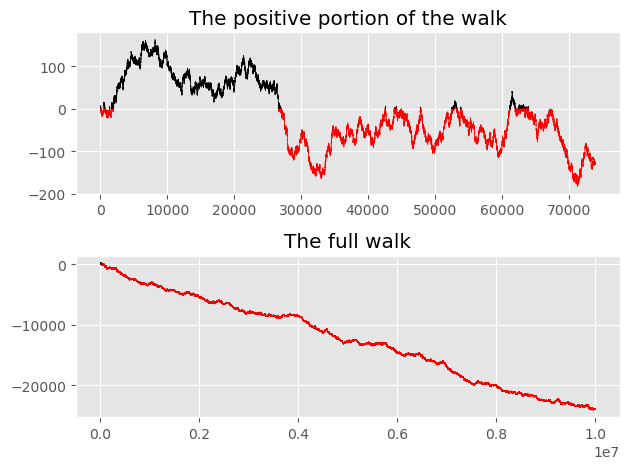

In [113]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
fig, axs = plt.subplots(2)
axs[0].scatter(x0, w0, s=0.01, c=c0)
axs[0].set_title("The positive portion of the walk")
axs[1].scatter(x1, w1, s=0.01, c=c1)
axs[1].set_title("The full walk")
plt.tight_layout()

__Answer the following questions in a markdown cell.__
* Can you recognize the gap sizes you found above in the positive picture?  Answer in about one sentence.
* Earlier you found what proportion of the way into the full walk do the values become negative, never to return to positive.  Can you recognize that in these pictures?  Answer in about one sentence.
* Why do you think we plot the full walk using `x1, w1` instead of using `x,w`?